In [2]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

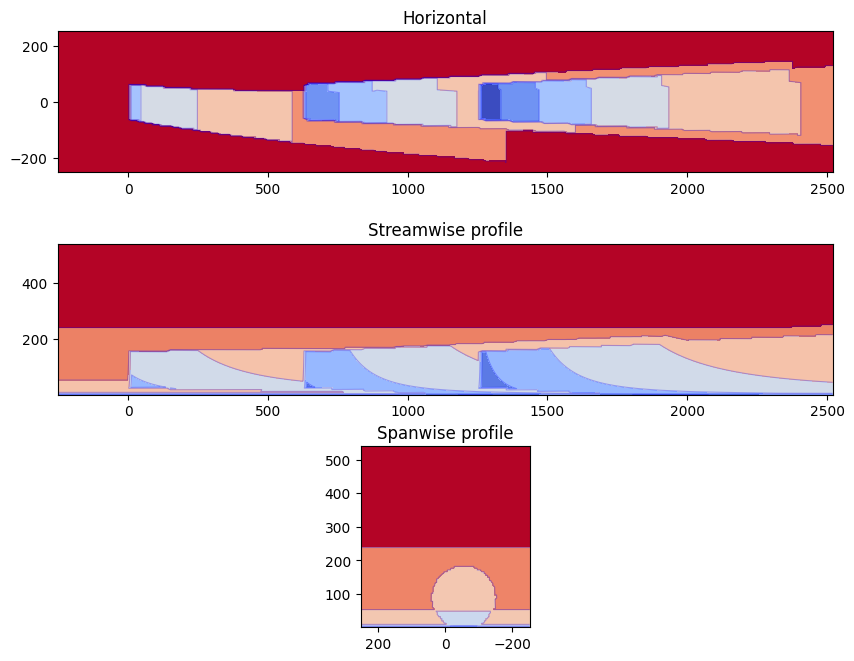

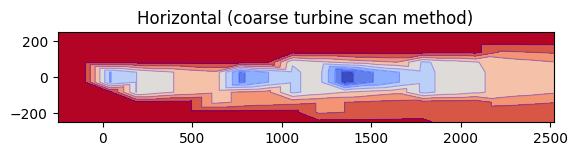

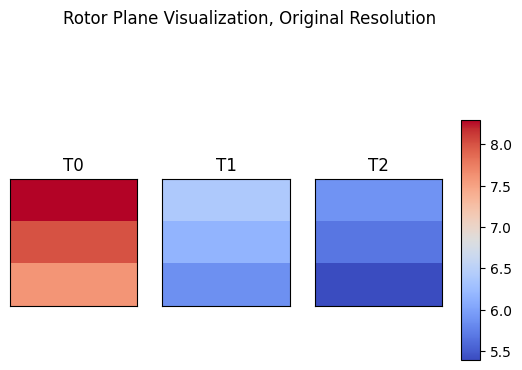

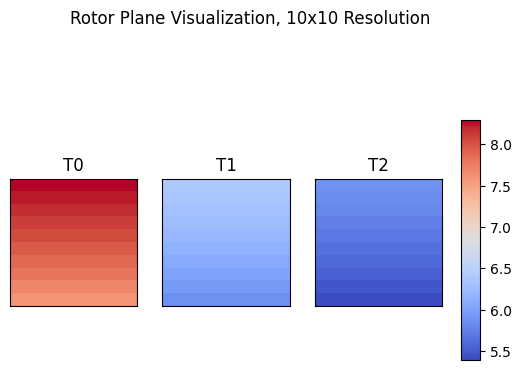

In [3]:

"""
This example initializes the FLORIS software, and then uses internal
functions to run a simulation and plot the results. In this case,
we are plotting three slices of the resulting flow field:
1. Horizontal slice parallel to the ground and located at the hub height
2. Vertical slice of parallel with the direction of the wind
3. Veritical slice parallel to to the turbine disc plane

Additionally, an alternative method of plotting a horizontal slice
is shown. Rather than calculating points in the domain behind a turbine,
this method adds an additional turbine to the farm and moves it to
locations throughout the farm while calculating the velocity at it's
rotor.
"""

# Initialize FLORIS with the given input file via FlorisInterface.
# For basic usage, FlorisInterface provides a simplified and expressive
# entry point to the simulation routines.
fi = FlorisInterface("nrel_jensen.yaml")

# The rotor plots show what is happening at each turbine, but we do not
# see what is happening between each turbine. For this, we use a
# grid that has points regularly distributed throughout the fluid domain.
# The FlorisInterface contains functions for configuring the new grid,
# running the simulation, and generating plots of 2D slices of the
# flow field.

# Note this visualization grid created within the calculate_horizontal_plane function will be reset
# to what existed previously at the end of the function

# Using the FlorisInterface functions, get 2D slices.
horizontal_plane = fi.calculate_horizontal_plane(
    x_resolution=200,
    y_resolution=100,
    height=90.0,
    yaw_angles=np.array([[[25.,0.,0.]]]),
)

y_plane = fi.calculate_y_plane(
    x_resolution=200,
    z_resolution=100,
    crossstream_dist=0.0,
    yaw_angles=np.array([[[25.,0.,0.]]]),
)
cross_plane = fi.calculate_cross_plane(
    y_resolution=100,
    z_resolution=100,
    downstream_dist=630.0,
    yaw_angles=np.array([[[25.,0.,0.]]]),
)

# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 8))
ax_list = ax_list.flatten()
wakeviz.visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
wakeviz.visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
wakeviz.visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")

# Some wake models may not yet have a visualization method included, for these cases can use
# a slower version which scans a turbine model to produce the horizontal flow
horizontal_plane_scan_turbine = calculate_horizontal_plane_with_turbines(
    fi,
    x_resolution=20,
    y_resolution=10,
    yaw_angles=np.array([[[25.,0.,0.]]]),
)

fig, ax = plt.subplots()
visualize_cut_plane(
    horizontal_plane_scan_turbine,
    ax=ax,
    title="Horizontal (coarse turbine scan method)",
)

# FLORIS further includes visualization methods for visualing the rotor plane of each
# Turbine in the simulation

# Run the wake calculation to get the turbine-turbine interfactions
# on the turbine grids
fi.calculate_wake()

# Plot the values at each rotor
fig, axes, _ , _ = wakeviz.plot_rotor_values(
    fi.floris.flow_field.u,
    wd_index=0,
    ws_index=0,
    n_rows=1,
    n_cols=3,
    return_fig_objects=True
)
fig.suptitle("Rotor Plane Visualization, Original Resolution")

# FLORIS supports multiple types of grids for capturing wind speed
# information. The current input file is configured with a square grid
# placed on each rotor plane with 9 points in a 3x3 layout. For visualization,
# this resolution can be increased.  Note this operation, unlike the
# calc_x_plane above operations does not automatically reset the grid to
# the initial status as definied by the input file

# Increase the resolution of points on each turbien plane
solver_settings = {
    "type": "turbine_grid",
    "turbine_grid_points": 10
}
fi.reinitialize(solver_settings=solver_settings)

# Run the wake calculation to get the turbine-turbine interfactions
# on the turbine grids
fi.calculate_wake()

# Plot the values at each rotor
fig, axes, _ , _ = wakeviz.plot_rotor_values(
    fi.floris.flow_field.u,
    wd_index=0,
    ws_index=0,
    n_rows=1,
    n_cols=3,
    return_fig_objects=True
)
fig.suptitle("Rotor Plane Visualization, 10x10 Resolution")

wakeviz.show_plots()
